In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd

os.makedirs("data/processed/graficos", exist_ok=True)

In [7]:
df_final_uf = pd.read_csv(r'C:\Arquivos Vsco\Projeto\Challenge Orale\data\csv final\dataset_unificado_uf_2023_2025.csv')

In [8]:
df_final_uf["LEITOS_POR_10K_HAB"] = (df_final_uf["Leitos existentes"] / df_final_uf["População residente"]) * 10000
df_final_uf["INTERNACOES_POR_LEITO"] = df_final_uf["TOTAL_INTERNACOES"] / df_final_uf["Leitos existentes"]
df_final_uf["TAXA_MORTALIDADE_HOSPITALAR"] = (df_final_uf["TOTAL_OBITOS_SIH"] / df_final_uf["TOTAL_INTERNACOES"]) * 100
df_final_uf["GASTO_MEDIO_INTERNACAO"] = df_final_uf["VALOR_TOTAL_SIH"] / df_final_uf["TOTAL_INTERNACOES"]

print(df_final_uf.shape)  # deve dar (81, 16) agora

(81, 16)


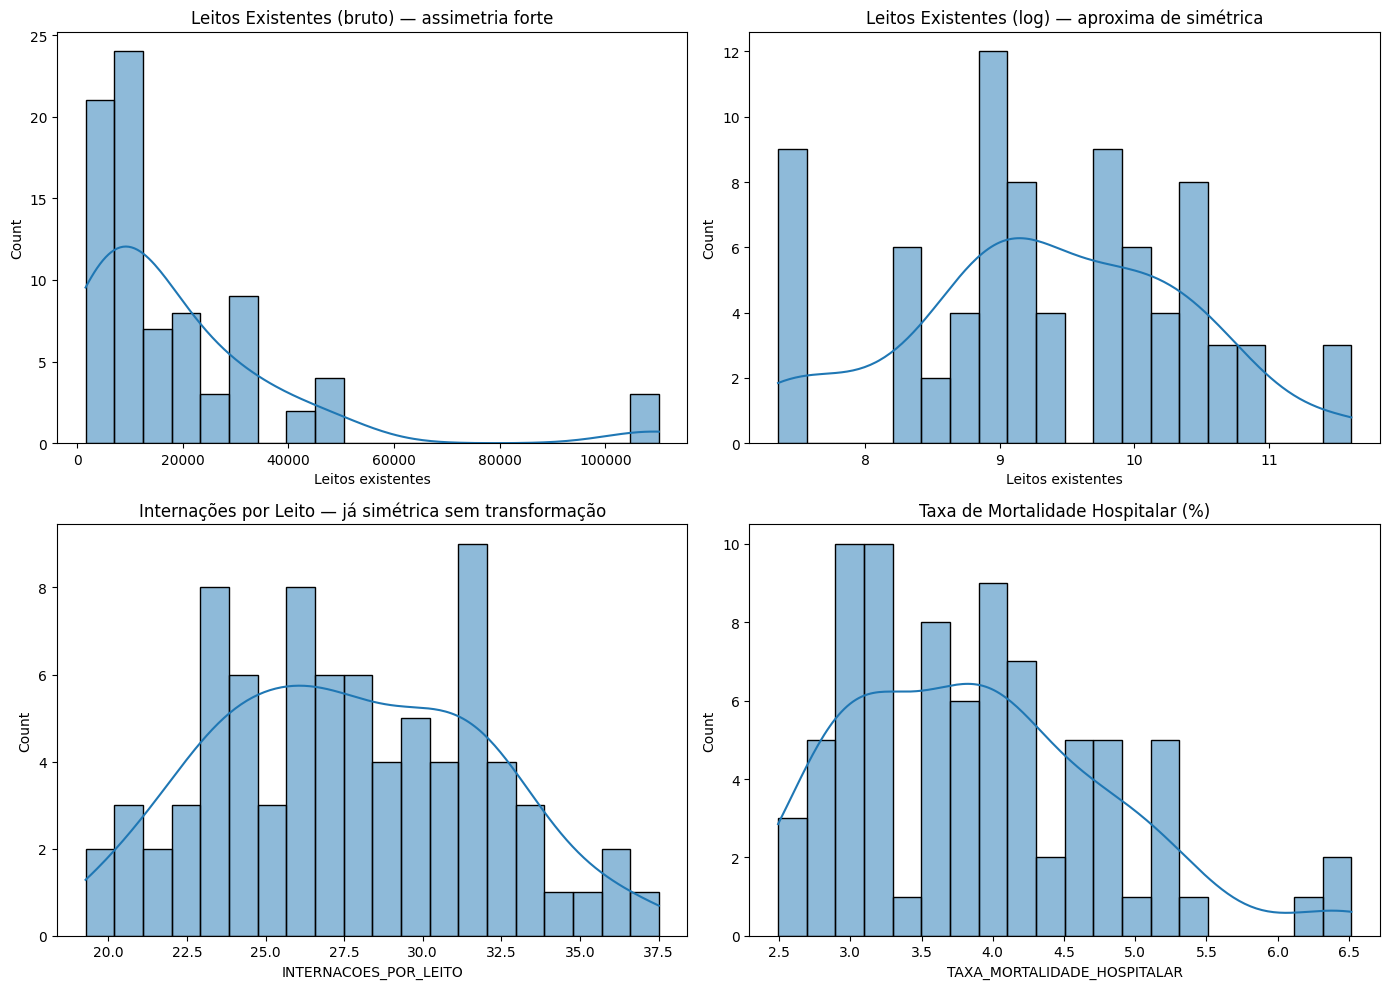

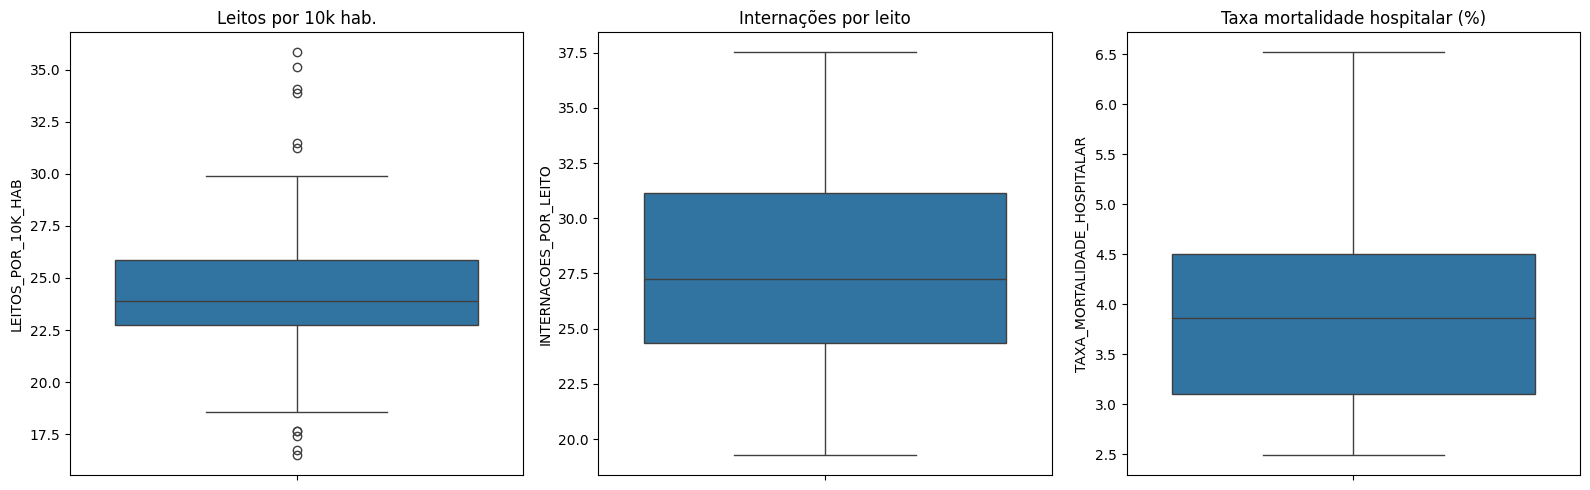

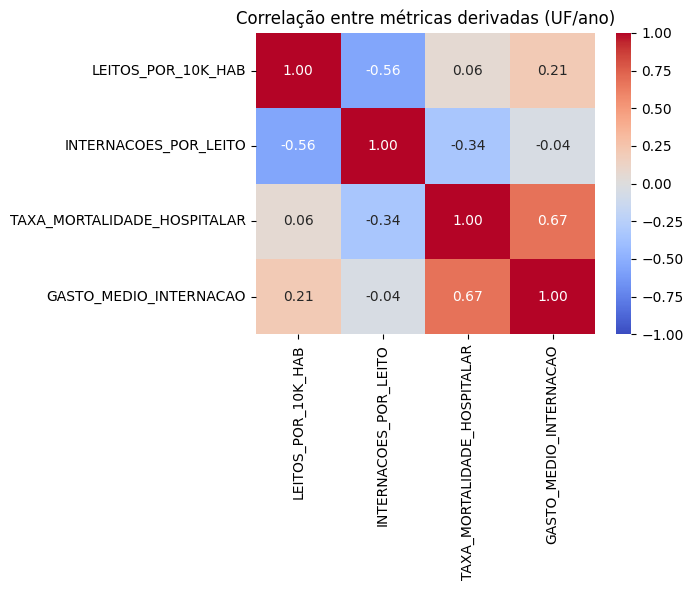

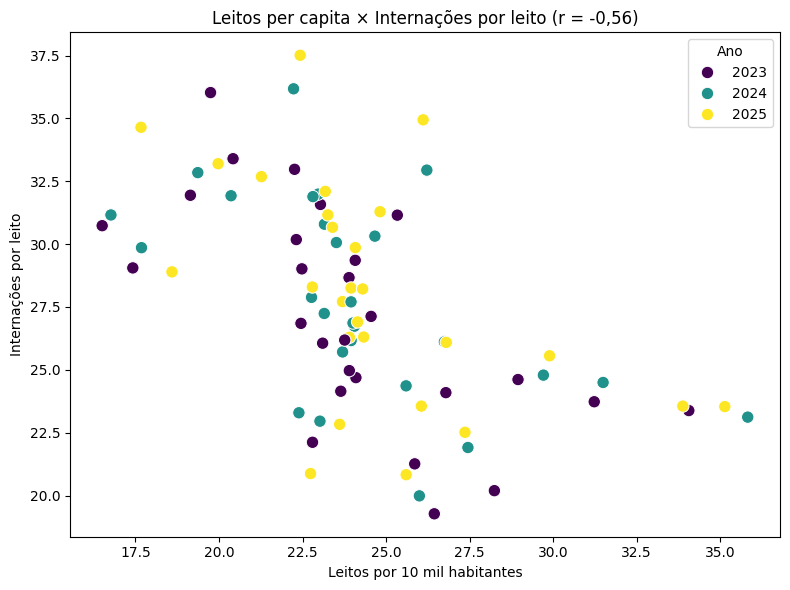

In [11]:
# --- 1. Histogramas: bruta vs. normalizada, lado a lado, pra mostrar visualmente a diferença de assimetria ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_final_uf["Leitos existentes"], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title("Leitos Existentes (bruto) — assimetria forte")

sns.histplot(np.log1p(df_final_uf["Leitos existentes"]), bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title("Leitos Existentes (log) — aproxima de simétrica")

sns.histplot(df_final_uf["INTERNACOES_POR_LEITO"], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title("Internações por Leito — já simétrica sem transformação")

sns.histplot(df_final_uf["TAXA_MORTALIDADE_HOSPITALAR"], bins=20, kde=True, ax=axes[1,1])
axes[1,1].set_title("Taxa de Mortalidade Hospitalar (%)")

plt.tight_layout()
plt.show()

# --- 2. Boxplots: outliers das variáveis brutas vs. derivadas ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df_final_uf["LEITOS_POR_10K_HAB"], ax=axes[0])
axes[0].set_title("Leitos por 10k hab.")

sns.boxplot(y=df_final_uf["INTERNACOES_POR_LEITO"], ax=axes[1])
axes[1].set_title("Internações por leito")

sns.boxplot(y=df_final_uf["TAXA_MORTALIDADE_HOSPITALAR"], ax=axes[2])
axes[2].set_title("Taxa mortalidade hospitalar (%)")

plt.tight_layout()
plt.show()

# --- 3. Heatmap de correlação (as métricas relevantes, já calculadas antes) ---
cols_corr = ["LEITOS_POR_10K_HAB", "INTERNACOES_POR_LEITO", "TAXA_MORTALIDADE_HOSPITALAR", "GASTO_MEDIO_INTERNACAO"]

plt.figure(figsize=(7, 6))
sns.heatmap(df_final_uf[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlação entre métricas derivadas (UF/ano)")
plt.tight_layout()
plt.show()

# --- 4. Scatter da correlação mais forte (visualiza a relação de pressão hospitalar) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final_uf, x="LEITOS_POR_10K_HAB", y="INTERNACOES_POR_LEITO", hue="Ano", palette="viridis", s=80)
plt.title("Leitos per capita × Internações por leito (r = -0,56)")
plt.xlabel("Leitos por 10 mil habitantes")
plt.ylabel("Internações por leito")
plt.tight_layout()
plt.show()